In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, smart_resize
from PIL import Image
from sklearn.model_selection import train_test_split
import zipfile
import pandas as pd

In [16]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [24]:
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [3]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

100%|██████████| 60.3M/60.3M [00:00<00:00, 161MB/s]

Extracting files...


In [4]:
# Set base directory for Colab
base_dir = os.path.expanduser("~/.cache/kagglehub/datasets/msambare/fer2013/versions/1")

# Define train and test paths
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Verify dataset paths
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# Check if dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

Train directory: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train
Test directory: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test


In [ ]:
# # Set paths if Training Locally
# base_dir = "/Users/danielarday/.cache/kagglehub/datasets/msambare/fer2013/versions/1"
# train_dir = os.path.join(base_dir, "train")
# test_dir = os.path.join(base_dir, "test")

## Simple CNN Model

In [ ]:
# from sklearn.utils import class_weight

# class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_true), y=y_true)
# class_weights = dict(enumerate(class_weights))

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Text(0.5, 1.0, 'Label: 4')

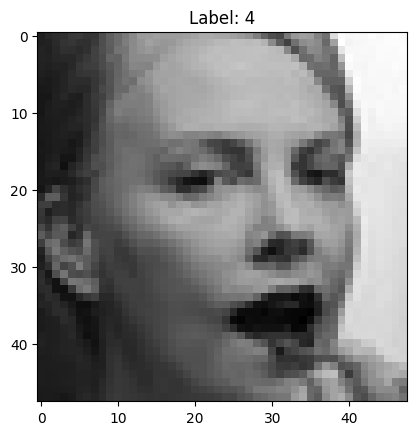

In [32]:
# Define ImageDataGenerator for preprocessing
datagen = ImageDataGenerator(
    rescale=1.0/255,
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='constant',
    validation_split=0.2  # Splitting train into train/validation
)

# Load images using ImageDataGenerator
batch_size = 64
img_size = (48, 48)

# Load images from directories
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

# Example: Get a batch of images
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")


# New Gens

In [30]:
# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    # rotation_range=10,
    # width_shift_range=0.1,
    # height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='constant',
    brightness_range=[0.9, 1.1],
    validation_split=0.2  # Split train into training and validation sets
)

# Validation generator (only rescale, no augmentation)
val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

# Test generator (only rescale)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load images using the generators
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


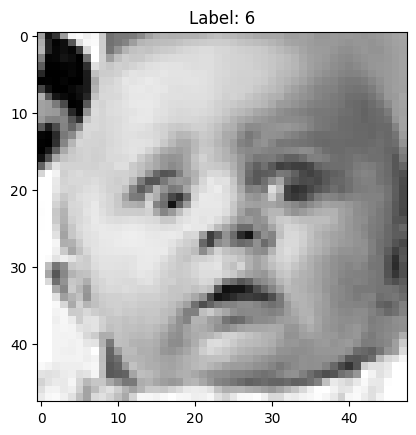

In [22]:
img_size = (48, 48)

# Custom preprocessing using smart_resize to maintain aspect ratio
def preprocess_smart_resize(image):
    resized_image = smart_resize(image, img_size)  # Resize to (48, 48)
    return resized_image / 255.0  # Normalize

# Example: Display a batch of processed images
images, labels = next(train_generator)
resized_image = preprocess_smart_resize(images[0])
plt.imshow(resized_image.squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

# Sped Up

In [34]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    horizontal_flip=True,
    fill_mode='constant',
    validation_split=0.2  # Split train into training and validation sets
)

# Load images using the generators
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Function to load and preprocess all images from a generator as Numpy arrays
def load_images(generator):
    images, labels = [], []
    for _ in range(len(generator)):
        img_batch, label_batch = next(generator)
        images.append(img_batch)
        labels.append(label_batch)
    return np.vstack(images), np.vstack(labels)

# Preload validation and test datasets
print("Preloading validation images...")
val_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
val_images, val_labels = load_images(val_generator)

print("Preloading test images...")
test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)
test_images, test_labels = load_images(test_generator)

print(f"Validation images shape: {val_images.shape}")
print(f"Test images shape: {test_images.shape}")

# Print class labels
print("Class Labels:", train_generator.class_indices)

Found 22968 images belonging to 7 classes.
Preloading validation images...
Found 5741 images belonging to 7 classes.
Preloading test images...
Found 7178 images belonging to 7 classes.
Validation images shape: (5741, 256, 256, 1)
Test images shape: (7178, 256, 256, 1)
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


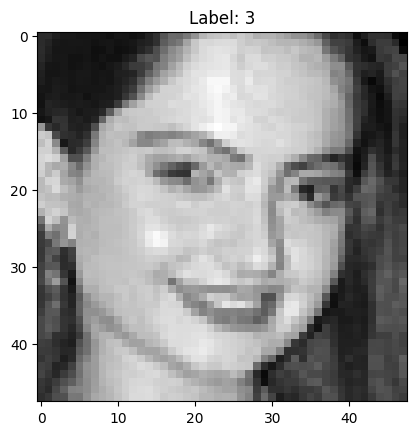

In [20]:
# Example: Display a batch of processed images
images, labels = next(train_generator)
resized_image = preprocess_smart_resize(images[0])
plt.imshow(resized_image.squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

# Improved

In [36]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Simpler Data Augmentation (REMOVED brightness)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    horizontal_flip=True,
    fill_mode='constant',
    validation_split=0.2
)

batch_size = 64

# Load Training Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Load Validation and Test Sets into Memory
def load_images(generator):
    images, labels = [], []
    for _ in range(len(generator)):
        img_batch, label_batch = next(generator)
        images.append(img_batch)
        labels.append(label_batch)
    return np.vstack(images), np.vstack(labels)

# Validation generator (only rescale, no augmentation)
val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

# Test generator (only rescale, no augmentation)
test_datagen = ImageDataGenerator(rescale=1.0/255)

print("Preloading validation images...")
val_generator = val_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
val_images, val_labels = load_images(val_generator)

print("Preloading test images...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)
test_images, test_labels = load_images(test_generator)

print(f"Validation images shape: {val_images.shape}")
print(f"Test images shape: {test_images.shape}")


Found 22968 images belonging to 7 classes.
Preloading validation images...
Found 5741 images belonging to 7 classes.
Preloading test images...
Found 7178 images belonging to 7 classes.
Validation images shape: (5741, 256, 256, 1)
Test images shape: (7178, 256, 256, 1)


In [ ]:
img_size = (48, 48)

# Custom preprocessing using smart_resize to maintain aspect ratio
def preprocess_smart_resize(image):
    resized_image = smart_resize(image, img_size)  # Resize to (48, 48)
    return resized_image / 255.0  # Normalize

# Example: Display a batch of processed images
images, labels = next(train_generator)
resized_image = preprocess_smart_resize(images[0])
plt.imshow(resized_image.squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

# Training

In [29]:
#For use with A100 Only

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [38]:
# Define the Model (Reduce Complexity Slightly)
num_classes = len(train_generator.class_indices)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(256, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')
])

# Optimizer with Learning Rate Decay
lr_schedule = ExponentialDecay(
    initial_learning_rate=5e-4,
    decay_steps=1000,
    decay_rate=0.95
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("fer_best_model.keras", save_best_only=True),
    # tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Train Model (Use Preloaded Validation Data)
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=(val_images, val_labels),
    callbacks=callbacks
)

# Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Final Test Accuracy: {test_acc:.4f}")

# Save the Final Model
model.save("fer_final_model.keras")

Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.2369 - loss: 1.8343 - val_accuracy: 0.2329 - val_loss: 1.8888
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.2638 - loss: 1.7762 - val_accuracy: 0.2581 - val_loss: 1.8632
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.2681 - loss: 1.7731 - val_accuracy: 0.2559 - val_loss: 2.1254
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.2824 - loss: 1.7622 - val_accuracy: 0.2576 - val_loss: 2.0717
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.2774 - loss: 1.7563 - val_accuracy: 0.2740 - val_loss: 1.7762
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.2815 - loss: 1.7509 - val_accuracy: 0.2780 - val_loss: 1.7582
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.2796 - loss: 1.7556 - val_accuracy: 0.2827 - val_loss: 1.7524
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.2844 - loss: 1.7512 - 

##Old

In [35]:
# Get the number of classes dynamically
num_classes = len(train_generator.class_indices)

# Define the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(256, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping and checkpoint callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("fer_best_model.h5", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

# Train the model
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks
)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Save full model (architecture + weights + optimizer)
model.save("fer_final_model.keras")

Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2415 - loss: 1.8316

359/359 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - accuracy: 0.2415 - loss: 1.8316 - val_accuracy: 0.1683 - val_loss: 1.9579 - learning_rate: 5.0000e-04
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2544 - loss: 1.7894

359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.2544 - loss: 1.7894 - val_accuracy: 0.2036 - val_loss: 1.8621 - learning_rate: 5.0000e-04
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2745 - loss: 1.7600 - val_accuracy: 0.2564 - val_loss: 1.9411 - learning_rate: 5.0000e-04
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2796 - loss: 1.7608

359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2796 - loss: 1.7608 - val_accuracy: 0.2597 - val_loss: 1.7926 - learning_rate: 5.0000e-04
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.2710 - loss: 1.7613 - val_accuracy: 0.2547 - val_loss: 1.8954 - learning_rate: 5.0000e-04
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2821 - loss: 1.7600

359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.2821 - loss: 1.7600 - val_accuracy: 0.2806 - val_loss: 1.7584 - learning_rate: 5.0000e-04
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2829 - loss: 1.7544 - val_accuracy: 0.2498 - val_loss: 1.7781 - learning_rate: 5.0000e-04
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2919 - loss: 1.7468 - val_accuracy: 0.2735 - val_loss: 1.9750 - learning_rate: 5.0000e-04
Epoch 9/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2896 - loss: 1.7468 - val_accuracy: 0.2564 - val_loss: 2.2514 - learning_rate: 2.5000e-04
Epoch 10/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.2957 - loss: 1.7339 - val_accuracy: 0.2628 - val_loss: 1.9359 - learning_rate: 2.5000e-04
Epoch 11/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2958 - loss: 1.7255

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.3190 - loss: 1.7028 - val_accuracy: 0.3094 - val_loss: 1.7114 - learning_rate: 6.2500e-05
Epoch 21/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3165 - loss: 1.7032 - val_accuracy: 0.2756 - val_loss: 1.8587 - learning_rate: 6.2500e-05
Epoch 22/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3207 - loss: 1.6989 - val_accuracy: 0.3043 - val_loss: 1.7563 - learning_rate: 6.2500e-05
Epoch 23/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3233 - loss: 1.7045 - val_accuracy: 0.3047 - val_loss: 1.7416 - learning_rate: 3.1250e-05
Epoch 24/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3129 - loss: 1.7059

359/359 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.3129 - loss: 1.7059 - val_accuracy: 0.3172 - val_loss: 1.7006 - learning_rate: 3.1250e-05
Epoch 25/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.3160 - loss: 1.7064 - val_accuracy: 0.3073 - val_loss: 1.7416 - learning_rate: 3.1250e-05
Epoch 26/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3176 - loss: 1.7034

359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3176 - loss: 1.7034 - val_accuracy: 0.3151 - val_loss: 1.6979 - learning_rate: 3.1250e-05
Epoch 27/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.3177 - loss: 1.7036 - val_accuracy: 0.3125 - val_loss: 1.7270 - learning_rate: 3.1250e-05
Epoch 28/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3228 - loss: 1.6946 - val_accuracy: 0.3175 - val_loss: 1.7044 - learning_rate: 3.1250e-05
Epoch 29/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3209 - loss: 1.7040 - val_accuracy: 0.3029 - val_loss: 1.7370 - learning_rate: 1.5625e-05
Epoch 30/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.3199 - loss: 1.7006 - val_accuracy: 0.3179 - val_loss: 1.7045 - learning_rate: 1.5625e-05
Epoch 31/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3247 - loss: 1.6938

359/359 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.3247 - loss: 1.6938 - val_accuracy: 0.3184 - val_loss: 1.6958 - learning_rate: 7.8125e-06
Epoch 32/40
101/359 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.3217 - loss: 1.7025

KeyboardInterrupt: 

#New

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# ✅ Check dataset paths
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found.")

# ✅ Stronger Data Augmentation (Removes Brightness)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,  # 🔥 Increased rotation
    width_shift_range=0.2,  # 🔥 Allow slight horizontal shift
    height_shift_range=0.2,  # 🔥 Allow slight vertical shift
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 🔥 Split into 80% train / 20% val
)

# ✅ Validation & Test: No Augmentation
val_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# ✅ Load Data Generators
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    train_dir, color_mode="grayscale", batch_size=batch_size, class_mode="categorical", subset="training"
)

val_generator = val_datagen.flow_from_directory(
    train_dir, color_mode="grayscale", batch_size=batch_size, class_mode="categorical", subset="validation", shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir, color_mode="grayscale", batch_size=batch_size, class_mode="categorical", shuffle=False
)

# ✅ Define Model with Regularization & Dropout
num_classes = len(train_generator.class_indices)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),  # 🔥 Increased dropout

    tf.keras.layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')
])

# ✅ Try Fixed Learning Rate First (1e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Callbacks (Early Stopping & Checkpoints)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("fer_best_model.keras", save_best_only=True)
]

# ✅ Train Model
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks
)

# ✅ Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_generator)
print(f"🔥 Final Test Accuracy: {test_acc:.4f}")

# ✅ Save the Final Model
model.save("fer_final_model.keras")

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 138s 341ms/step - accuracy: 0.2286 - loss: 2.3313 - val_accuracy: 0.2513 - val_loss: 2.3141
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 105s 291ms/step - accuracy: 0.2466 - loss: 2.2211 - val_accuracy: 0.2599 - val_loss: 2.2968
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 106s 295ms/step - accuracy: 0.2464 - loss: 2.1677 - val_accuracy: 0.2531 - val_loss: 2.1932
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 105s 292ms/step - accuracy: 0.2594 - loss: 2.1186 - val_accuracy: 0.2402 - val_loss: 2.1207
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 106s 294ms/step - accuracy: 0.2567 - loss: 2.0748 - val_accuracy: 0.2592 - val_loss: 2.0619
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 105s 292ms/step - accuracy: 0.2683 - loss: 2.0378 - val_accuracy: 0.2592 - val_loss: 2.0933
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 105s 292ms/step - accuracy: 0.2687 - loss

# Original

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


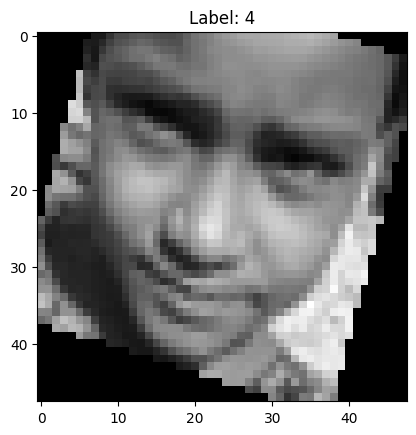

In [35]:
# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Define Training Data Generator (With Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.15,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='constant',  # Keep constant to avoid misleading artifacts
    validation_split=0.2
)

# Define Validation Data Generator (Only Rescaling, No Augmentation)
val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2  # Uses the same split but without augmentations
)

# Define Test Data Generator (Only Rescaling, No Augmentation)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load Images for Training
batch_size = 64
img_size = (48, 48)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Load Images for Validation (Using val_datagen to avoid augmentation)
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Load Images for Testing (Using test_datagen)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

# Display Example Image
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1641 - loss: 2.6754

359/359 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.1641 - loss: 2.6741 - val_accuracy: 0.2001 - val_loss: 2.0887
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1319 - loss: 1.9440

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.1319 - loss: 1.9440 - val_accuracy: 0.1752 - val_loss: 1.9329
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1247 - loss: 1.9367

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3307 - loss: 1.6746 - val_accuracy: 0.4255 - val_loss: 1.4809
Epoch 16/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.3334 - loss: 1.6666 - val_accuracy: 0.4398 - val_loss: 1.5056
Epoch 17/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3595 - loss: 1.6419 - val_accuracy: 0.3114 - val_loss: 1.6921
Epoch 18/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3553 - loss: 1.6030

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3553 - loss: 1.6030 - val_accuracy: 0.4442 - val_loss: 1.4551
Epoch 19/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3638 - loss: 1.5918

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3638 - loss: 1.5919 - val_accuracy: 0.4558 - val_loss: 1.4345
Epoch 20/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.3641 - loss: 1.6104 - val_accuracy: 0.4548 - val_loss: 1.4914
Epoch 21/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3863 - loss: 1.5641

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3863 - loss: 1.5642 - val_accuracy: 0.4727 - val_loss: 1.3784
Epoch 22/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.3911 - loss: 1.5542 - val_accuracy: 0.4443 - val_loss: 1.6642
Epoch 23/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4065 - loss: 1.5215

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.4064 - loss: 1.5216 - val_accuracy: 0.4835 - val_loss: 1.3580
Epoch 24/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3993 - loss: 1.5160 - val_accuracy: 0.4593 - val_loss: 1.4010
Epoch 25/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.4044 - loss: 1.5458 - val_accuracy: 0.4618 - val_loss: 1.4241
Epoch 26/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4189 - loss: 1.4883 - val_accuracy: 0.4586 - val_loss: 1.4122
Epoch 27/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4095 - loss: 1.4915 - val_accuracy: 0.4497 - val_loss: 1.4108
Epoch 28/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4247 - loss: 1.4751 - val_accuracy: 0.4379 - val_loss: 1.4509
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3616 - loss: 1.4923
Test Accuracy: 0.4854


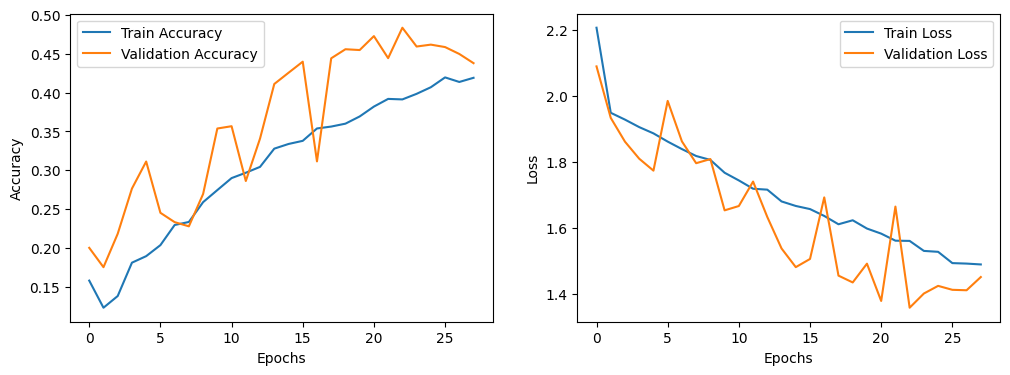

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the number of classes dynamically
num_classes = len(train_generator.class_indices)

# Define the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping & Model Checkpoint
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("fer_best_model.h5", save_best_only=True)
]

# Compute class weights dynamically
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# Train model with class weights
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights,  # Add this
    callbacks=callbacks
)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# NEXT

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


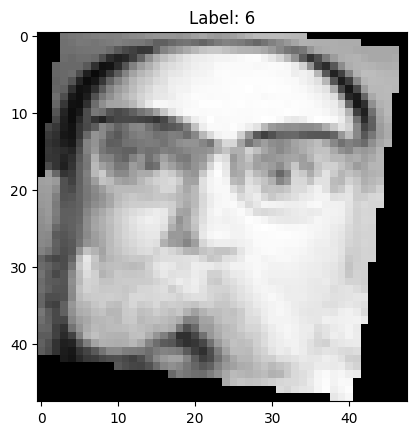

In [112]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Define Training Data Generator (With Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,  # Reduced from 20
    width_shift_range=0.1,  # Reduced from 0.2
    height_shift_range=0.1,  # Reduced from 0.2
    zoom_range=0.2,
    shear_range=0.2,  # NEW: Perspective distortions
    # brightness_range=[0.8, 1.2],  # NEW: More varied lighting
    horizontal_flip=True,
    fill_mode='constant',  # Keep constant to avoid misleading artifacts
    validation_split=0.2
)

# Define Validation & Test Data Generator (Only Rescaling, No Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

# Load Images for Training
batch_size = 64
img_size = (48, 48)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Load Images for Validation (Using val_test_datagen to avoid augmentation)
val_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Load Images for Testing (Using test_datagen)
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

# Display Example Image
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

Epoch 1/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2309 - loss: 2.5019

359/359 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.2310 - loss: 2.5001 - val_accuracy: 0.2789 - val_loss: 1.9421 - learning_rate: 3.0000e-04
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3258 - loss: 1.8014

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3258 - loss: 1.8013 - val_accuracy: 0.3839 - val_loss: 1.6308 - learning_rate: 3.0000e-04
Epoch 3/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3791 - loss: 1.6687

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3792 - loss: 1.6686 - val_accuracy: 0.4484 - val_loss: 1.5236 - learning_rate: 3.0000e-04
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4213 - loss: 1.5539

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4213 - loss: 1.5539 - val_accuracy: 0.4926 - val_loss: 1.3856 - learning_rate: 3.0000e-04
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4541 - loss: 1.4821 - val_accuracy: 0.4853 - val_loss: 1.4810 - learning_rate: 3.0000e-04
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.4769 - loss: 1.4268 - val_accuracy: 0.4860 - val_loss: 1.4118 - learning_rate: 3.0000e-04
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5030 - loss: 1.3765

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5030 - loss: 1.3764 - val_accuracy: 0.5168 - val_loss: 1.3258 - learning_rate: 3.0000e-04
Epoch 8/50
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5229 - loss: 1.3326

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5229 - loss: 1.3326 - val_accuracy: 0.5365 - val_loss: 1.2642 - learning_rate: 3.0000e-04
Epoch 9/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.5299 - loss: 1.3181 - val_accuracy: 0.5504 - val_loss: 1.2656 - learning_rate: 3.0000e-04
Epoch 10/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5350 - loss: 1.2955 - val_accuracy: 0.5259 - val_loss: 1.3681 - learning_rate: 3.0000e-04
Epoch 11/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.5491 - loss: 1.2719 - val_accuracy: 0.5419 - val_loss: 1.2932 - learning_rate: 3.0000e-04
Epoch 12/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.5624 - loss: 1.2401 - val_accuracy: 0.5379 - val_loss: 1.3056 - learning_rate: 3.0000e-04
Epoch 13/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5654 - loss: 1.2179 - val_accuracy: 0.5253 - val_loss: 1.3432 - learning_rate: 3.0000e-04
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.495

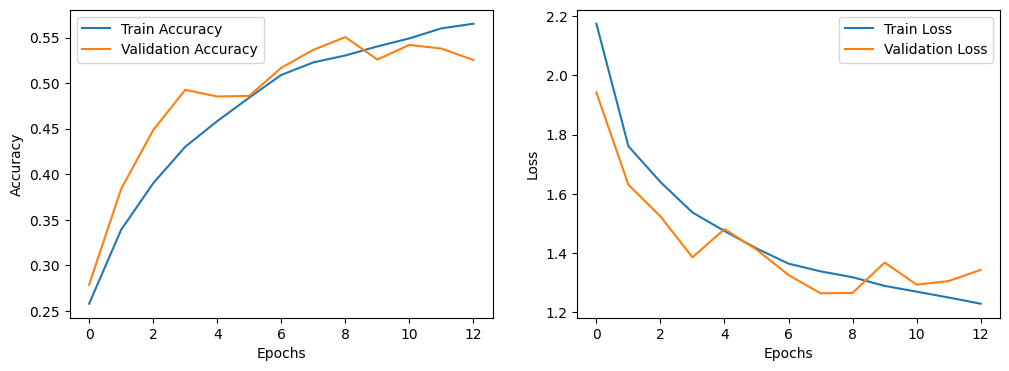

In [41]:
# Get the number of classes dynamically
num_classes = len(train_generator.class_indices)

# Define the Improved CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0001), input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # NEW: Swapped one MaxPooling for AveragePooling

    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.0001)),  # NEW: Added 512-filter Conv Layer
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.6),  # NEW: Increased dropout to reduce overfitting
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)  # NEW: Lower initial learning rate
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping & Model Checkpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("fer_best_model.h5", save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)  # NEW: Adaptive Learning Rate
]

# Train model (Removed class weighting in favor of augmentation)
history = model.fit(
    train_generator,
    epochs=50,  # NEW: Increased epochs
    validation_data=val_generator,
    callbacks=callbacks
)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2020 - loss: 2.8400

359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.2020 - loss: 2.8398 - val_accuracy: 0.2517 - val_loss: 2.4975 - learning_rate: 1.0000e-04
Epoch 2/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2341 - loss: 2.5833

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.2341 - loss: 2.5831 - val_accuracy: 0.2728 - val_loss: 2.3288 - learning_rate: 1.0000e-04
Epoch 3/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2496 - loss: 2.4664

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5456 - loss: 1.5147 - val_accuracy: 0.5732 - val_loss: 1.4239 - learning_rate: 1.0000e-04
Epoch 31/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5521 - loss: 1.5121 - val_accuracy: 0.5579 - val_loss: 1.4718 - learning_rate: 1.0000e-04
Epoch 32/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5396 - loss: 1.5126

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5396 - loss: 1.5126 - val_accuracy: 0.5827 - val_loss: 1.4094 - learning_rate: 1.0000e-04
Epoch 33/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5489 - loss: 1.4886

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5489 - loss: 1.4886 - val_accuracy: 0.5875 - val_loss: 1.3837 - learning_rate: 1.0000e-04
Epoch 34/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5571 - loss: 1.4586 - val_accuracy: 0.5694 - val_loss: 1.4030 - learning_rate: 1.0000e-04
Epoch 35/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5549 - loss: 1.4594 - val_accuracy: 0.5851 - val_loss: 1.3978 - learning_rate: 1.0000e-04
Epoch 36/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5565 - loss: 1.4558 - val_accuracy: 0.5727 - val_loss: 1.4027 - learning_rate: 1.0000e-04
Epoch 37/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5658 - loss: 1.4377 - val_accuracy: 0.5813 - val_loss: 1.3979 - learning_rate: 1.0000e-04
Epoch 38/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5654 - loss: 1.4304

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5654 - loss: 1.4304 - val_accuracy: 0.5865 - val_loss: 1.3672 - learning_rate: 1.0000e-04
Epoch 39/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5604 - loss: 1.4222 - val_accuracy: 0.5743 - val_loss: 1.3909 - learning_rate: 1.0000e-04
Epoch 40/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5622 - loss: 1.4168

359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5622 - loss: 1.4168 - val_accuracy: 0.5901 - val_loss: 1.3546 - learning_rate: 1.0000e-04
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5428 - loss: 1.4580
Test Accuracy: 0.5931


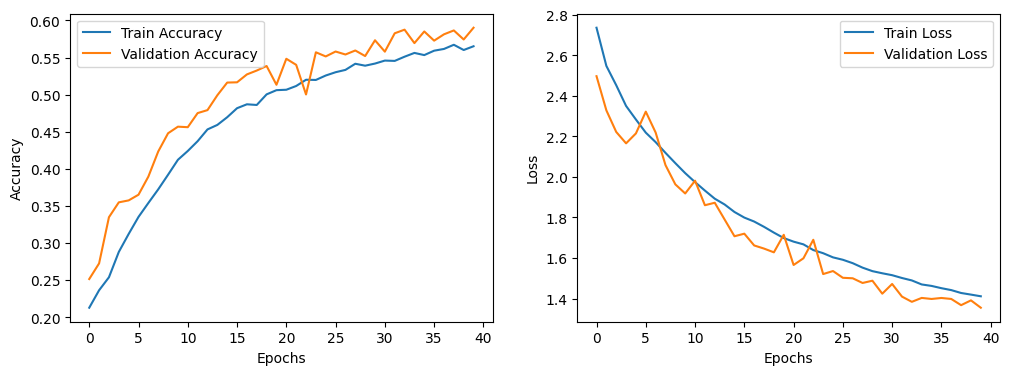

In [113]:
# Get the number of classes dynamically
num_classes = len(sample_gen.class_indices)  # Use sample_gen which has class_indices

# Define the Improved CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # Swapped one MaxPooling for AveragePooling
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # Added pooling after 512 conv layer
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(512, (1, 1), activation='relu', kernel_regularizer=l2(0.0005)),  # Extra conv layer to extract final features
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),  # Replaces Flatten to reduce overfitting
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # Lowered LR
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping & Model Checkpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint("fer_best_model.h5", save_best_only=True,save_freq='epoch'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)  # Adaptive Learning Rate
]

# Train model (Removed class weighting in favor of augmentation)
history = model.fit(
    train_generator,
    epochs=40,  # Increased epochs to allow better convergence
    validation_data=val_generator,
    callbacks=callbacks
)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Weighted Augmentation

## Transfer Learning Model ( EfficientNetB0 )

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load EfficientNetB0 without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze base model (so only new layers train initially)
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Replaces Flatten()
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)  # num_classes from train_generator.class_indices

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

# Train only the top layers first
history = model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=callbacks)

# Unfreeze the base model and fine-tune everything
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
history_finetune = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=callbacks)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

16705208/16705208 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 48, 48, 3)            0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 48, 48, 3)            7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     

                                                                                                  
 block2a_se_excite (Multipl  (None, 12, 12, 96)           0         ['block2a_activation[0][0]',  
 y)                                                                  'block2a_se_expand[0][0]']   
                                                                                                  
 block2a_project_conv (Conv  (None, 12, 12, 24)           2304      ['block2a_se_excite[0][0]']   
 2D)                                                                                              
                                                                                                  
 block2a_project_bn (BatchN  (None, 12, 12, 24)           96        ['block2a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block2b_e

 block3a_se_excite (Multipl  (None, 6, 6, 144)            0         ['block3a_activation[0][0]',  
 y)                                                                  'block3a_se_expand[0][0]']   
                                                                                                  
 block3a_project_conv (Conv  (None, 6, 6, 40)             5760      ['block3a_se_excite[0][0]']   
 2D)                                                                                              
                                                                                                  
 block3a_project_bn (BatchN  (None, 6, 6, 40)             160       ['block3a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block3b_expand_conv (Conv2  (None, 6, 6, 240)            9600      ['block3a_project_bn[0][0]']  
 D)       

 y)                                                                  'block4a_se_expand[0][0]']   
                                                                                                  
 block4a_project_conv (Conv  (None, 3, 3, 80)             19200     ['block4a_se_excite[0][0]']   
 2D)                                                                                              
                                                                                                  
 block4a_project_bn (BatchN  (None, 3, 3, 80)             320       ['block4a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block4b_expand_conv (Conv2  (None, 3, 3, 480)            38400     ['block4a_project_bn[0][0]']  
 D)                                                                                               
          

                                                                                                  
 block4c_project_bn (BatchN  (None, 3, 3, 80)             320       ['block4c_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block4c_drop (Dropout)      (None, 3, 3, 80)             0         ['block4c_project_bn[0][0]']  
                                                                                                  
 block4c_add (Add)           (None, 3, 3, 80)             0         ['block4c_drop[0][0]',        
                                                                     'block4b_add[0][0]']         
                                                                                                  
 block5a_expand_conv (Conv2  (None, 3, 3, 480)            38400     ['block4c_add[0][0]']         
 D)       

 block5b_drop (Dropout)      (None, 3, 3, 112)            0         ['block5b_project_bn[0][0]']  
                                                                                                  
 block5b_add (Add)           (None, 3, 3, 112)            0         ['block5b_drop[0][0]',        
                                                                     'block5a_project_bn[0][0]']  
                                                                                                  
 block5c_expand_conv (Conv2  (None, 3, 3, 672)            75264     ['block5b_add[0][0]']         
 D)                                                                                               
                                                                                                  
 block5c_expand_bn (BatchNo  (None, 3, 3, 672)            2688      ['block5c_expand_conv[0][0]'] 
 rmalization)                                                                                     
          

                                                                                                  
 block6a_project_bn (BatchN  (None, 2, 2, 192)            768       ['block6a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block6b_expand_conv (Conv2  (None, 2, 2, 1152)           221184    ['block6a_project_bn[0][0]']  
 D)                                                                                               
                                                                                                  
 block6b_expand_bn (BatchNo  (None, 2, 2, 1152)           4608      ['block6b_expand_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 block6b_e

 block6c_drop (Dropout)      (None, 2, 2, 192)            0         ['block6c_project_bn[0][0]']  
                                                                                                  
 block6c_add (Add)           (None, 2, 2, 192)            0         ['block6c_drop[0][0]',        
                                                                     'block6b_add[0][0]']         
                                                                                                  
 block6d_expand_conv (Conv2  (None, 2, 2, 1152)           221184    ['block6c_add[0][0]']         
 D)                                                                                               
                                                                                                  
 block6d_expand_bn (BatchNo  (None, 2, 2, 1152)           4608      ['block6d_expand_conv[0][0]'] 
 rmalization)                                                                                     
          

                                                                                                  
 top_conv (Conv2D)           (None, 2, 2, 1280)           409600    ['block7a_project_bn[0][0]']  
                                                                                                  
 top_bn (BatchNormalization  (None, 2, 2, 1280)           5120      ['top_conv[0][0]']            
 )                                                                                                
                                                                                                  
 top_activation (Activation  (None, 2, 2, 1280)           0         ['top_bn[0][0]']              
 )                                                                                                
                                                                                                  
 global_average_pooling2d (  (None, 1280)                 0         ['top_activation[0][0]']      
 GlobalAve

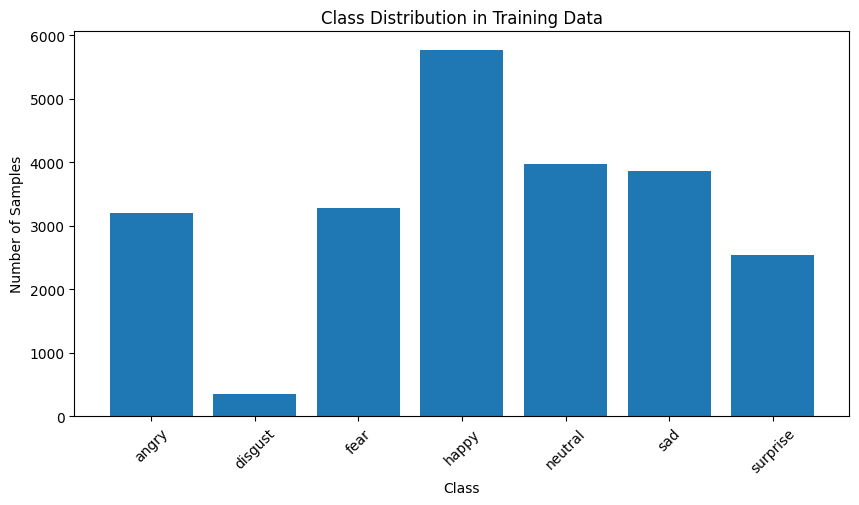

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Get class counts
class_counts = Counter(train_generator.classes)
class_labels = list(train_generator.class_indices.keys())

# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_labels, [class_counts[i] for i in range(len(class_labels))])
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Data")
plt.xticks(rotation=45)
plt.show()

In [96]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Found 28709 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Found 28709 images belonging to 7 classes.


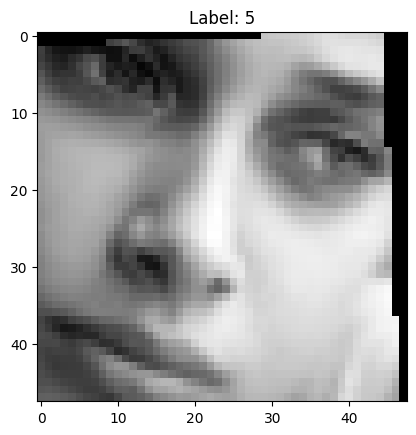

In [114]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Define Different Augmentations for Class Imbalance Handling
strong_aug = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=8,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='constant'
)

moderate_aug = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode='constant'
)

light_aug = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=2,
    width_shift_range=0.02,
    height_shift_range=0.02,
    zoom_range=0.05,
    shear_range=0.02,
    horizontal_flip=True,
    fill_mode='constant'
)

# Define Class Augmentation Mapping
minority_classes = {"disgust", "surprise"}
moderate_classes = {"angry", "fear", "sad"}
majority_classes = {"happy", "neutral"}

def get_augmentation(class_name):
    """Returns the augmentation strategy based on the class imbalance level."""
    if class_name in minority_classes:
        return strong_aug
    elif class_name in moderate_classes:
        return moderate_aug
    else:
        return light_aug

# Define Base Generator Without Augmentation
base_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

# First Call to Get Class Indices Dynamically
sample_gen = base_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=1,  # Small batch to get class mappings
    class_mode="categorical"
)

# Store Class Labels
class_indices = sample_gen.class_indices

# Now Define Augmentation Mapping After Fetching Class Names
class_aug_map = {k: get_augmentation(k) for k in class_indices.keys()}

def custom_weighted_generator(directory, batch_size=128, img_size=(48, 48)):
    """
    Custom data generator that applies different augmentations based on class, efficiently applying augmentation to entire batches.
    """
    base_gen = base_datagen.flow_from_directory(
        directory,
        target_size=img_size,
        color_mode="grayscale",
        batch_size=batch_size,
        class_mode="categorical"
    )

    while True:
        images, labels = next(base_gen)

        # Get the class indices for the batch
        class_idx = np.argmax(labels, axis=1)

        # Group images by augmentation level
        aug_images = np.zeros_like(images)

        for class_name in class_indices.keys():
            # Find indices of images belonging to this class
            class_indices_in_batch = np.where(np.array([list(class_indices.keys())[i] for i in class_idx]) == class_name)[0]

            if len(class_indices_in_batch) > 0:
                aug = class_aug_map[class_name]

                # Apply augmentation to all images of this class in batch
                aug_gen = aug.flow(images[class_indices_in_batch], batch_size=len(class_indices_in_batch), shuffle=False)
                aug_images[class_indices_in_batch] = next(aug_gen)  # Apply augmentations

        yield aug_images, labels


batch_size=512

# Instantiate Train Generator Using Custom Weighted Augmentation
train_generator = custom_weighted_generator(train_dir, batch_size=batch_size)

train_dataset = tf.data.Dataset.from_generator(lambda: train_generator, output_signature=(
    tf.TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(None, num_classes), dtype=tf.float32)
)).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# Load Validation and Test Generators (Without Augmentation)
val_generator = base_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = base_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print Class Labels
print("Class Labels:", class_indices)

# Display an Example Image After Augmentation
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

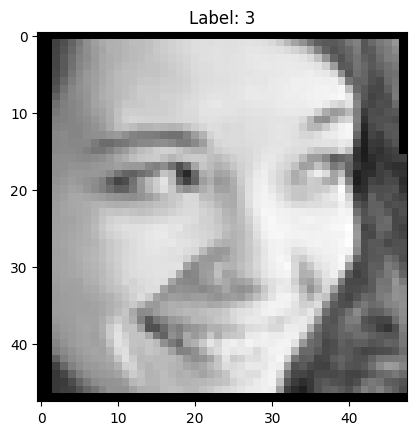

In [107]:
# Display an Example Image After Augmentation
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

## ResNet

Images need to be in RGB for ResNet

In [ ]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze base model (so only new layers train initially)
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Replaces Flatten()
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)  # num_classes from train_generator.class_indices

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

# Train only the top layers first
history = model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=callbacks)

# Unfreeze the base model and fine-tune everything
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
history_finetune = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=callbacks)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 54, 54, 3)            0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 24, 24, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 24, 24, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                        

                                                                                                  
 conv2_block3_1_conv (Conv2  (None, 12, 12, 64)           16448     ['conv2_block2_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv2_block3_1_bn (BatchNo  (None, 12, 12, 64)           256       ['conv2_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv2_block3_1_relu (Activ  (None, 12, 12, 64)           0         ['conv2_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv2_blo

 ation)                                                                                           
                                                                                                  
 conv3_block2_3_conv (Conv2  (None, 6, 6, 512)            66048     ['conv3_block2_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv3_block2_3_bn (BatchNo  (None, 6, 6, 512)            2048      ['conv3_block2_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv3_block2_add (Add)      (None, 6, 6, 512)            0         ['conv3_block1_out[0][0]',    
                                                                     'conv3_block2_3_bn[0][0]']   
          

 conv4_block1_2_conv (Conv2  (None, 3, 3, 256)            590080    ['conv4_block1_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block1_2_bn (BatchNo  (None, 3, 3, 256)            1024      ['conv4_block1_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block1_2_relu (Activ  (None, 3, 3, 256)            0         ['conv4_block1_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block1_0_conv (Conv2  (None, 3, 3, 1024)           525312    ['conv3_block4_out[0][0]']    
 D)       

                                                                                                  
 conv4_block3_out (Activati  (None, 3, 3, 1024)           0         ['conv4_block3_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv4_block4_1_conv (Conv2  (None, 3, 3, 256)            262400    ['conv4_block3_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv4_block4_1_bn (BatchNo  (None, 3, 3, 256)            1024      ['conv4_block4_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_blo

 D)                                                                                               
                                                                                                  
 conv4_block6_3_bn (BatchNo  (None, 3, 3, 1024)           4096      ['conv4_block6_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block6_add (Add)      (None, 3, 3, 1024)           0         ['conv4_block5_out[0][0]',    
                                                                     'conv4_block6_3_bn[0][0]']   
                                                                                                  
 conv4_block6_out (Activati  (None, 3, 3, 1024)           0         ['conv4_block6_add[0][0]']    
 on)                                                                                              
          

 conv5_block3_1_relu (Activ  (None, 2, 2, 512)            0         ['conv5_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv5_block3_2_conv (Conv2  (None, 2, 2, 512)            2359808   ['conv5_block3_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv5_block3_2_bn (BatchNo  (None, 2, 2, 512)            2048      ['conv5_block3_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block3_2_relu (Activ  (None, 2, 2, 512)            0         ['conv5_block3_2_bn[0][0]']   
 ation)   

/opt/anaconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


359/359 [==============================] - 532s 1s/step - loss: 1.1753 - accuracy: 0.5569 - val_loss: 1.2150 - val_accuracy: 0.5348
Epoch 7/15
359/359 [==============================] - 529s 1s/step - loss: 1.1379 - accuracy: 0.5715 - val_loss: 1.2011 - val_accuracy: 0.5424
Epoch 8/15
359/359 [==============================] - 533s 1s/step - loss: 1.1062 - accuracy: 0.5814 - val_loss: 1.1741 - val_accuracy: 0.5574
Epoch 9/15
359/359 [==============================] - 530s 1s/step - loss: 1.0935 - accuracy: 0.5882 - val_loss: 1.1758 - val_accuracy: 0.5569
Epoch 10/15
359/359 [==============================] - 535s 1s/step - loss: 1.0580 - accuracy: 0.6041 - val_loss: 1.2284 - val_accuracy: 0.5569
Epoch 11/15
359/359 [==============================] - 537s 1s/step - loss: 1.0413 - accuracy: 0.6102 - val_loss: 1.1369 - val_accuracy: 0.5799
Epoch 12/15
359/359 [==============================] - 19329s 54s/step - loss: 1.0135 - accuracy: 0.6210 - val_loss: 1.1776 - val_accuracy: 0.5720
Epoc

# **FINAL MODEL**

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


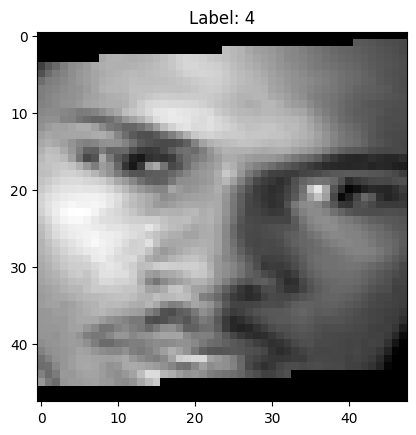

In [117]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Define Training Data Generator (With Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,  # Reduced from 20
    width_shift_range=0.1,  # Reduced from 0.2
    height_shift_range=0.1,  # Reduced from 0.2
    zoom_range=0.2,
    shear_range=0.2,  # NEW: Perspective distortions
    # brightness_range=[0.8, 1.2],  # NEW: More varied lighting
    horizontal_flip=True,
    fill_mode='constant',  # Keep constant to avoid misleading artifacts
    validation_split=0.2
)

# Define Validation & Test Data Generator (Only Rescaling, No Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

# Load Images for Training
batch_size = 64
img_size = (48, 48)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Load Images for Validation (Using val_test_datagen to avoid augmentation)
val_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Load Images for Testing (Using test_datagen)
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

# Display Example Image
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.2036 - loss: 2.7611 - val_accuracy: 0.2541 - val_loss: 2.4495 - learning_rate: 3.0000e-04
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.2420 - loss: 2.4499 - val_accuracy: 0.2698 - val_loss: 2.4243 - learning_rate: 3.0000e-04
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3047 - loss: 2.2873 - val_accuracy: 0.3696 - val_loss: 2.1279 - learning_rate: 3.0000e-04
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3530 - loss: 2.1566 - val_accuracy: 0.4369 - val_loss: 1.9483 - learning_rate: 3.0000e-04
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.4021 - loss: 2.0351 - val_accuracy: 0.4719 - val_loss: 1.8574 - learning_rate: 3.0000e-04
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4414 - loss: 1.9163 - val_accuracy: 0.4748 - val_loss: 1.8003 - learning_rate: 3.0000e-04
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/ste

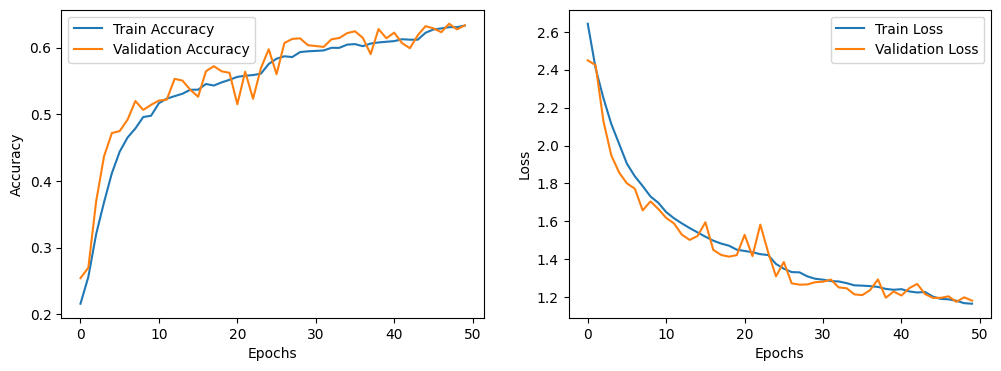

In [119]:
# Get the number of classes dynamically
num_classes = len(train_generator.class_indices)
# num_classes = len(sample_gen.class_indices)  # Use sample_gen which has class_indices

# Define the Improved CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # Swapped one MaxPooling for AveragePooling
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # Added pooling after 512 conv layer
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(512, (1, 1), activation='relu', kernel_regularizer=l2(0.0005)),  # Extra conv layer to extract final features
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),  # Replaces Flatten to reduce overfitting
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping & Model Checkpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint("fer_best_model.keras", save_best_only=True, save_freq='epoch'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)  # Adaptive Learning Rate
]

# Train model (Removed class weighting in favor of augmentation)
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Visualization

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Overall Accuracy: 0.6414
              precision    recall  f1-score   support

       angry       0.54      0.59      0.57       958
     disgust       0.83      0.35      0.49       111
        fear       0.55      0.32      0.41      1024
       happy       0.86      0.86      0.86      1774
     neutral       0.50      0.78      0.61      1233
         sad       0.59      0.40      0.48      1247
    surprise       0.73      0.81      0.77       831

    accuracy                           0.64      7178
   macro avg       0.66      0.59      0.60      7178
weighted avg       0.65      0.64      0.63      7178



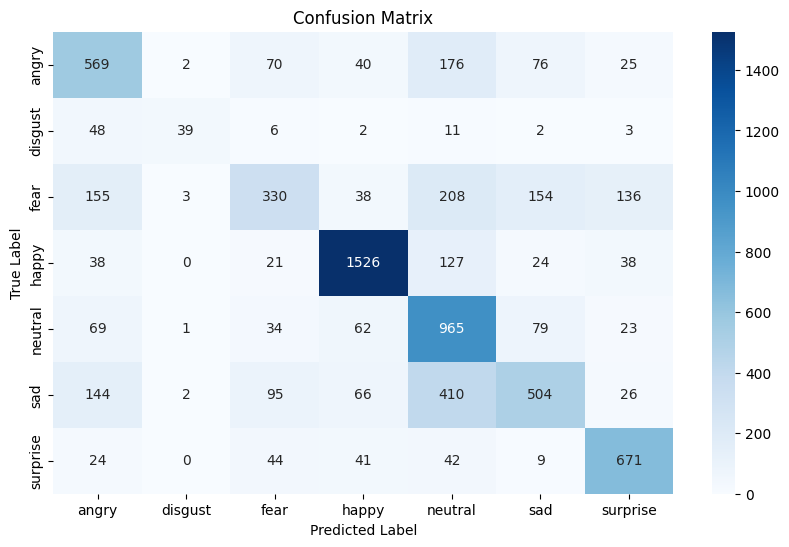

In [129]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Get true labels and predictions
y_true = test_generator.classes  # True labels
y_pred = model.predict(test_generator)  # Probabilities
y_pred_classes = y_pred.argmax(axis=1)  # Convert to class labels

# Compute accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Overall Accuracy: {accuracy:.4f}")  # Print overall accuracy

# Print classification report
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [121]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5972 - loss: 1.2613
Test Accuracy: 0.6414


### **Brief Analysis**

- overall accuracy of the model is **64.14%**, indicating a moderate level of performance across the seven emotion classes.  
- **Happy (86%) and Surprise (73%)** were classified with high precision and recall, suggesting that these emotions are well-represented and easily distinguishable.  
- **Neutral (50% precision, 78% recall)** shows a strong recall, meaning many neutral faces are correctly classified, but some misclassifications occur.  
- **Fear (55% precision, 32% recall), Sad (59% precision, 40% recall), and Angry (54% precision, 59% recall)** struggled, particularly in recall, meaning these emotions are often confused with others.  
- **Disgust (83% precision, 35% recall)** had a **low recall**, meaning most disgusted faces were misclassified, likely due to the small sample size.  
- The **macro-average F1-score of 60%** suggests that performance varies across classes, with minority classes suffering more.  
- Overall, the model performs well on dominant emotions but may need further data balancing or fine-tuning for **fear, sad, and disgust** to improve recall.